## Esercitazione 7 -  9 Aprile 2024

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import sympy as sym
import IPython.display as nb
import radixmethods as meth
from displayutils import *
from sympy.utilities.lambdify import lambdify
from funcutils import FunctionApprox
from more_itertools import iterate
from itertools import takewhile



#Costants
tolx = 1e-12
tolf = 1e-12
maxit =  lambda a, b: math.ceil(math.log2((b - a) / tolx))-1
nmax = 1000



Scrivere la function `NewtonRaphson_corde.py`, che implementa il metodo di Newton-Raphson con la variante delle corde
per il calcolo della soluzione di un sistema di equazioni non lineari. 

``` python
    def newton_raphson_chord(f, J, X0, tolx, tolf, nmax):
        return newton_raphson(f, J, X0, tolx, tolf, nmax, s=lambda f, J, X: -np.linalg.solve(J(x0), f(X)))
```

deve assumere come dati in input:
- fname: nome della funzione vettoriale di cui calcolare lo zero;
- JacName: nome della funzione che calcola lo J acobiano della funzione vettoriale;
- X0: vettore contenente le componenti dell'iterato iniziale);
- tolx tolleranza  per il test d'arresto sull'incremento
        $\frac{||X_{k+1}-X_k||}{||X_{k}||}<= tolx$
- tolf tolleranza per il test del residuo
        $||F(X_{k+1})|| <= tolf$
- NMAX numero massimo di iterazioni.
In output devono essere restituiti il vettore contenente l'approssimazione dello zero x, un vettore contenente l'errore relativo tra due iterati successivi, il numero di iterazioni
effettuate, nit.

Scrivere la function `NewtonRaphson_sham.py`, che implementa il metodo di Newton-Raphson con la variante di Shamanskii
per il calcolo della soluzione di un sistema di equazioni non lineari. 

    Tale function
deve assumere come dati in input:
- fname: nome della funzione vettoriale di cui calcolare lo zero;
- JacName: nome della funzione che calcola lo J acobiano della funzione vettoriale;
- X0: vettore contenente le componenti dell'iterato iniziale);
- tolx tolleranza  per il test d'arresto sull'incremento
        ||X_{k+1}-X_k||/||X_{k}||<= tolx
- tolf tolleranza per il test del residuo
        ||F(Xk+1)|| <= tolf;
- NMAX numero massimo di iterazioni.
In output devono essere restituiti il vettore contenente l'approssimazione dello zero x, un vettore contenente l'errore relativo tra due iterati successivi, il numero di iterazioni
effettuate, nit.



Risolvere i seguenti tre sistemi non lineari:
1) 
$
\begin{cases}
   2x_0-\cos(x_1)=0\\
   \sin(x_0)+2x_1=0
\end{cases}
$

2) 
$
\begin{cases}
   x_0^2+x_1^2-9=0\\
   x_0+x_1-3=0
\end{cases}
$

3) 
$
\begin{cases}
   4x_0^2+x_1^2=4\\
   x_0+x_1=\sin(x_0-x_1)
\end{cases}
$


utilizzando il metodo di Newton Raphson, la variante delle corde e la variante di Shamanskii.
Confrontare per ciascun metodo il grafico dell'errore relativo tra due iterati successivi.

In [44]:
def Jacobian (funcs, var, literal=False):
    return np.array([[fun.partial_derivative(str(s))[0] if not literal else fun.partial_derivative(str(s))[1] for s in var] for fun in funcs])
        

def plot_err_relative(method, real, i):
        col=('grey', 'blue', 'red', 'orange', 'yellow', 'lightgreen', 'green', 'black')
        z, it, err = method
        plt.semilogy(np.arange(it), err, "o-")

def print_system_data(fun_symb, functions, real_val, sol=False):
    print("\nBasic system infos:\n")
    r = np.arange(-4.0, 4.0, 0.01)
    funcs = [FunctionApprox(fun, symbols=fun_symb, notation=f'f_{i}') for i, fun in enumerate(functions[0])]
    
    # [plot_contour(r, r, fun.func, i, fun.func_latex) for i, fun in enumerate(funcs)]

    # [plot_3D_projection(r, r, fun.func) for fun in funcs]
    
    J = lambda X: np.array([[fu(*X) for i, fu in enumerate(v)] for v in Jacobian(funcs, fun_symb)])
    f = lambda X: np.array([fun(*X) for fun in [fun.func for fun in funcs]])

    newthon_raphson_variants = {
        "newthon-raphson": meth.newton_raphson_optimized, "chord": meth.newton_raphson_chord, 'shamski': meth.newton_raphson_sham
    }
    if sol:
        results_normal = [meth.newton_raphson_optimized(f, J, x0, tolx, tolf, nmax) for x0 in functions[1]]
        
        [display_vector(z, notation=f"s_{i}") for i, (z, _, _) in enumerate(results_normal)]

        for index, met in enumerate(newthon_raphson_variants.values()):
            for _, x0 in enumerate(functions[1]):
                plot_err_relative(met(f, J, x0, tolx, tolf, nmax), real=np.array(real_val), i=index)

        plt.legend(list(newthon_raphson_variants.keys()))
        plt.show()
    
        

In [47]:
symbs = sym.symbols('x y')
systems_eq = {
    1: ((lambda x0, x1: 2 * x0 - sym.cos(x1), lambda x0, x1: sym.sin(x0) + 2 * x1),
        [[1, 2]]),
    2: ((lambda x0, x1: x0**2 + x1**2 - 9,  lambda x0, x1: x0 + x1 - 3),
        [[4, 0]]),
    3: ((lambda x0, x1: 4 * x0**2 + x1**2 - 4, lambda x0, x1: x0 + x1 - sym.sin(x0-x1)),
      [[1, 0]])
}
solutions = [[0.48641, -0.23373], [3, 0], [0.99861,-0.10553]]


Basic system infos:



<IPython.core.display.Latex object>

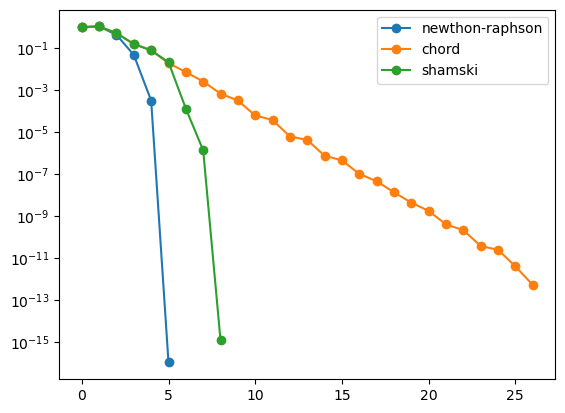


Basic system infos:



<IPython.core.display.Latex object>

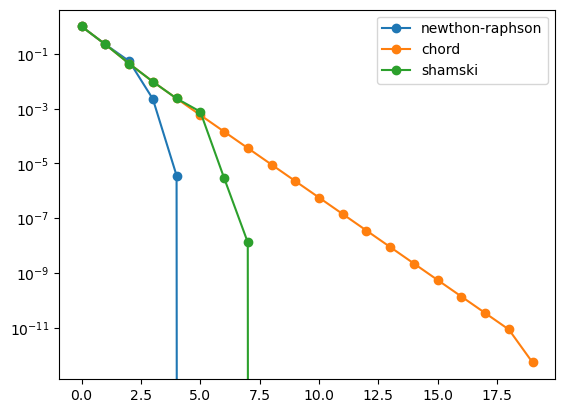


Basic system infos:



<IPython.core.display.Latex object>

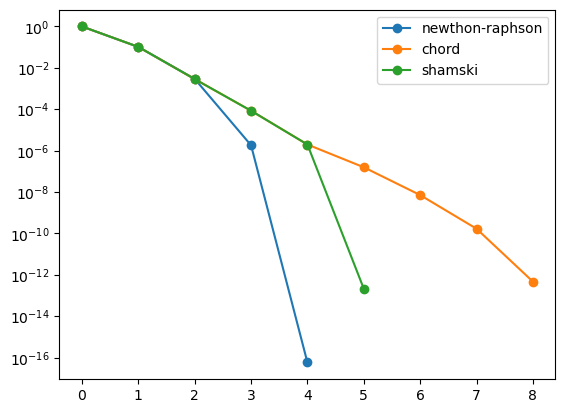

[None, None, None]

In [48]:
[print_system_data(symbs, data, solutions[i-1], sol=True) for i, data in systems_eq.items()]

## Esercizio 2
Scrivere la function `NewtonRaphson_minimo.py`, che implementa il metodo di Newton-Raphson con la variante delle corde
per il calcolo del minimo assoluto (relativo) di una funzione non lineare.

    Tale function
deve assumere come dati in input:
- grad_name: nome della  funzione vettoriale  che contine il gradiente della funzione di cui calcolare lo zero;
- Hess_name: nome della funzione che calcola l' Hessiana della funzione vettoriale;
- X0: vettore contenente le componenti dell'iterato iniziale);
- tolx tolleranza  per il test d'arresto sull'incremento
        ||X_{k+1}-X_k||/||X_{k}||<= tolx
- tolf tolleranza per il test del residuo
        ||F(Xk+1)|| <= tolf;
- NMAX numero massimo di iterazioni.
In output devono essere restituiti il vettore contenente l'approssimazione dello zero x, un vettore contenente l'errore relativo tra due iterati successivi, il numero di iterazioni
effettuate, nit.



## Esercizio 3
Scrivere una funzione numpy che calcola la norma infinito e la norma 1 di un vettore ed una matrice  e testarla su vettori e matrici  a propria scelta. Confrontarne i risultati con quelli ottenuti utilizzando la funzione norm di numpy.linalg

(Ricorda la formula della norma infinito e della norma 1 di una matrice
$||A||_\infty= \max_{j=1,n} \sum_{i} |a_{ij}| $
$\quad ||A||_1= \max_{i=1,n} \sum_{j} |a_{ij}| $)

In [1]:
show_norm = lambda p, norm, comment="", mat_name="A": \
    nb.display( \
        nb.Latex( \
            f"{comment}: $||{mat_name}||_"+"{"+f"{str(p)}"+"}"+ f"={norm}$" \
        ) \
    ) 

In [2]:
norm_inf = lambda A: max(np.sum(np.abs(A), axis=1))
norm1 = lambda A: max(np.sum(np.abs(A), axis=0))

In [81]:
#input
A = np.array([[2, -3], [4, 5]])
display_matrix(A, notation='A')
#solutions
show_norm(1, norm1(A), comment="Implemented Norm 1")
show_norm("\infty", norm_inf(A), comment="Implemented Norm Infinity")
show_norm(1, np.linalg.norm(A, 1), comment="Numpy algo for Norm 1")
show_norm("\infty", np.linalg.norm(A, np.inf), comment="Numpy algo for Norm Infinity")


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

## Esercizio 4
Implementare una funzione che calcola la norma 2 di una  matrice facendo uso della funzione eigvals del pacchetto numpy.linalg, (np.linalg.eigvals(A)). Testarla sulla matrice A=np.array([[4,-1,6],[2,3,-3],[1,-2,9/2]])   e confrontarne i risultati con quelli ottenuti utilizzando la funzione norm di numpy.linalg

In [106]:
norm2 = lambda A: np.sqrt(np.max(np.linalg.eigvals(np.transpose(A) @ A)))
norm2SE = lambda A: np.sqrt(np.sum(A**2))

In [109]:
#input
A = np.array([[4,-1,6],[2,3,-3],[1,-2,9/2]])
display_matrix(A, notation='A')
#solutions
show_norm(2, np.linalg.norm(A, 2), comment="Numpy algo for Norm 2")
show_norm(2, norm2(A), comment="Implemented Norm 2")
show_norm(2, norm2SE(A), comment="Implemented Norm 2 GEN/APROX")


<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>